In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, Delaunay

# Relaxation Example Figures

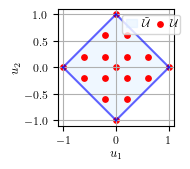

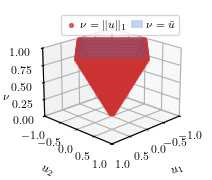

In [4]:
# Figure size
fig_width = 3.4
fig_height = 1.8

# Font settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.rm": "Times New Roman",
    'text.usetex': True,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7
})

# Define discrete input set U
u_max = 1
U_vertices = np.array([[u_max, 0], [-u_max, 0], [0, u_max], [0, -u_max]])
U_origin = np.zeros((1,2))

# W_extra = np.array([[0.5, 0.5], [-0.5, -0.5]])

# Step size for extra points
step = 0.4

# Create a grid of points
grid = np.arange(-1, 1 + step, step)
W_extra = []

for u1 in grid:
    for u2 in grid:
        if abs(u1) + abs(u2) <= 1 and (u1 != 0 or u2 != 0):  # exclude origin if desired
            W_extra.append([u1, u2])

W_extra = np.array(W_extra)

U = np.vstack([U_origin, U_vertices, W_extra])

# Create figure
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))
hull = ConvexHull(U_vertices)
ax1.fill(U_vertices[hull.vertices,0], U_vertices[hull.vertices,1],
         color=[0.8,0.9,1.0], alpha=0.3, label=r'$\tilde{\mathcal{U}}$')
for simplex in hull.simplices:
    ax1.plot(U_vertices[simplex, 0], U_vertices[simplex, 1], 'b-', alpha=0.6)
ax1.scatter(U[:,0], U[:,1], c='r', s=15, label=r'$\mathcal{U}$')
ax1.set_xlabel(r'$u_1$', labelpad=2)
ax1.set_ylabel(r'$u_2$', labelpad=2)
ax1.set_aspect('equal')
ax1.grid(True)

ax1.legend(
    loc='upper right',             # position
    fontsize=8,
    bbox_to_anchor=(1.10, 1),     # outside plot
    ncol=2,                        # horizontal layout
    frameon=True,                 # remove box for compactness
    handlelength=1,                # shorten legend marker length
    handletextpad=0.3,             # space between marker and text
    columnspacing=0.5              # space between columns
)


plt.tight_layout()
plt.savefig("2d_set.pdf", bbox_inches='tight')
plt.show()


# Prepare grids for 3D plot
tri = Delaunay(U_vertices)
u1 = np.linspace(-u_max, u_max, 50)
u2 = np.linspace(-u_max, u_max, 50)
U1, U2 = np.meshgrid(u1, u2)
points = np.vstack([U1.ravel(), U2.ravel()]).T
mask = tri.find_simplex(points) >= 0
U1_masked = points[mask,0]
U2_masked = points[mask,1]
Nu_lower = np.abs(U1_masked) + np.abs(U2_masked)
Nu_upper = np.max(np.sum(np.abs(U), axis=1)) * np.ones_like(Nu_lower)

# Create figure
fig = plt.figure(figsize=(fig_width, fig_height))
ax2 = fig.add_subplot(111, projection='3d')

# Scatter and surface
ax2.scatter(U1_masked, U2_masked, Nu_lower, color=[0.8,0.2,0.2], alpha=0.7, s=8, label=r'$\nu = \|u\|_1$')
ax2.plot_trisurf(U1_masked, U2_masked, Nu_upper, color=[0.3,0.6,1.0], alpha=0.3, edgecolor='none', label=r'$\nu = \bar{u}$')

# Axis labels (closer)
ax2.set_xlabel(r'$u_1$', labelpad=2)
ax2.set_ylabel(r'$u_2$', labelpad=2)
ax2.text(x=u_max + 1.8,             # slightly offset from the x_max plane
         y=0,                         # center along y-axis
         z=np.max(Nu_upper)/2 + 0.3,        # center along z-axis
         s=r'$\nu$', 
         color='black', 
         fontsize=8,
         rotation=90,                  # rotate label vertically along z
         va='center', ha='left')      # align text

# Tick labels closer
ax2.tick_params(axis='x', pad=1)
ax2.tick_params(axis='y', pad=1)
ax2.tick_params(axis='z', pad=1)

# Optional: tighten limits
ax2.set_xlim(-u_max, u_max)
ax2.set_ylim(-u_max, u_max)
ax2.set_zlim(0, np.max(np.sum(np.abs(U), axis=1)))

# View and grid
ax2.view_init(elev=20, azim=45)
ax2.grid(True)

# Compact horizontal legend
ax2.legend(
    loc='upper right',
    fontsize=8,
    ncol=2,
    frameon=True,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=0.5
)

plt.tight_layout()
plt.savefig("3d_set.pdf", bbox_inches='tight')
plt.show()
